In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

x = breast_cancer.data
y = breast_cancer.target

In [50]:
df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)


df["target"] = breast_cancer.target

columns = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "worst radius",
    "worst texture",
    "worst perimeter",
    "worst area",
    "target"
]


print(df[columns].head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   worst radius  worst texture  worst perimeter  worst area  target  
0         25.38          17.33           184.60      2019.0       0  
1         24.99          23.41           158.80      1956.0       0  
2         23.57          25.53           152.50      1709.0       0  
3         14.91          26.50            98.87       567.7       0  
4         22.54          16.67           152.20      1575.0       0  


=== MISSING VALUES PER FEATURE ===
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Total Missing Values Across Dataset: 0


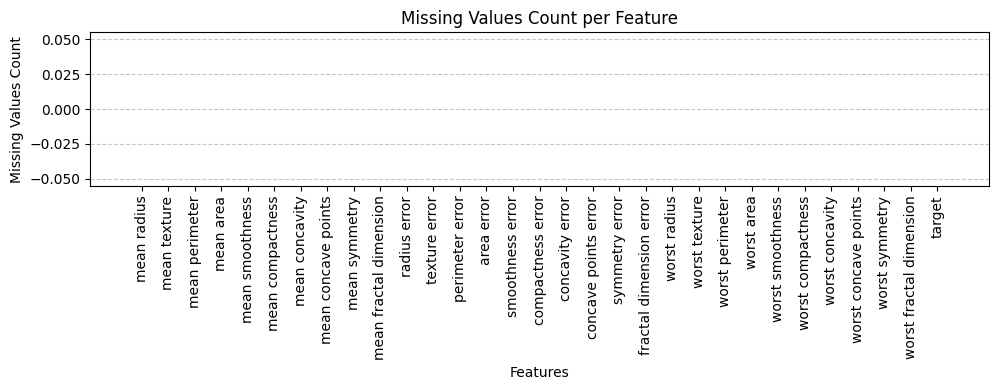

In [48]:
missing_values = df.isnull().sum()

print("=== MISSING VALUES PER FEATURE ===")
print(missing_values)
print("\nTotal Missing Values Across Dataset:", missing_values.sum())

plt.figure(figsize=(10, 4))
plt.bar(missing_values.index, missing_values.values, color='#2b5c8f')

plt.xlabel("Features")
plt.ylabel("Missing Values Count")
plt.title("Missing Values Count per Feature")
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [39]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=10000, random_state=42)
log_model.fit(x_train, y_train)
pred_log = log_model.predict(x_test)

In [22]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)
pred_dt = dt_model.predict(x_test)

In [46]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, pred_log),
        precision_score(y_test, pred_log, average='weighted'),
        recall_score(y_test, pred_log, average='weighted'),
        f1_score(y_test, pred_log, average='weighted')
    ],
    "Decision Tree": [
        accuracy_score(y_test, pred_dt),
        precision_score(y_test, pred_dt, average='weighted'),
        recall_score(y_test, pred_dt, average='weighted'),
        f1_score(y_test, pred_dt, average='weighted')
    ]
}

comparison_df = pd.DataFrame(metrics_data)

print("=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

=== MODEL PERFORMANCE COMPARISON ===
   Metric  Logistic Regression  Decision Tree
 Accuracy             0.956140       0.947368
Precision             0.956905       0.947368
   Recall             0.956140       0.947368
 F1-Score             0.955801       0.947368


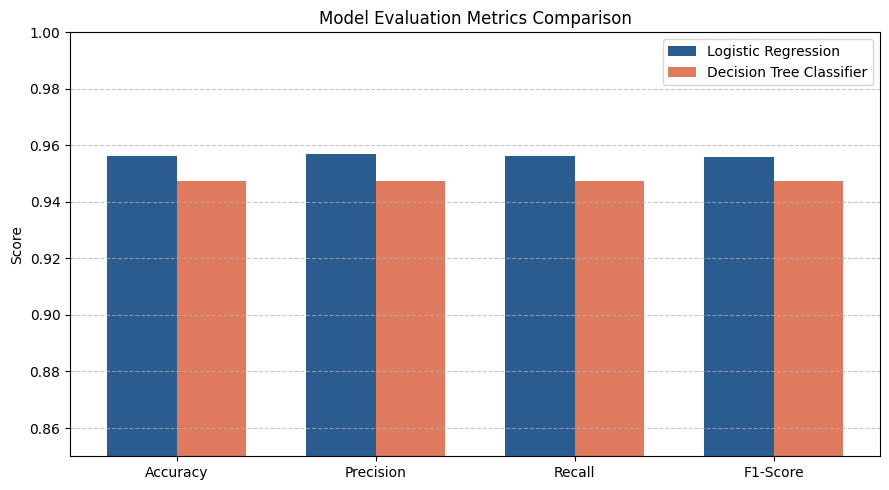

In [41]:
import numpy as np
import matplotlib.pyplot as plt

x_indices = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x_indices - width/2, log_metrics, width, label='Logistic Regression', color='#2b5c8f')
plt.bar(x_indices + width/2, dt_metrics, width, label='Decision Tree Classifier', color='#e07a5f')

plt.ylabel('Score')
plt.title('Model Evaluation Metrics Comparison')
plt.xticks(x_indices, metrics_names)
plt.ylim(0.85, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [47]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== LOGISTIC REGRESSION PREDICTIONS ===")
print(pred_log)

print("\n=== DECISION TREE PREDICTIONS ===")
print(pred_dt)

# 1. Calculate metrics for both models
metrics_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, pred_log),
        precision_score(y_test, pred_log, average='weighted'),
        recall_score(y_test, pred_log, average='weighted'),
        f1_score(y_test, pred_log, average='weighted')
    ],
    "Decision Tree": [
        accuracy_score(y_test, pred_dt),
        precision_score(y_test, pred_dt, average='weighted'),
        recall_score(y_test, pred_dt, average='weighted'),
        f1_score(y_test, pred_dt, average='weighted')
    ]
}

# 2. Create DataFrame
comparison_df = pd.DataFrame(metrics_data)

# 3. Print formatted comparison table
print("=== MODEL PERFORMANCE COMPARISON ===")
print(comparison_df.to_string(index=False))

=== LOGISTIC REGRESSION PREDICTIONS ===
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]

=== DECISION TREE PREDICTIONS ===
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]
=== MODEL PERFORMANCE COMPARISON ===
   Metric  Logistic Regression  Decision Tree
 Accuracy             0.956140       0.947368
Precision             0.956905       0.947368
   Recall             0.956140       0.947368
 F1-Score             0.955801       0.947368


In [30]:
|print("\n=== DECISION TREE CLASSIFIER EVALUATION ===")
print("Predictions:")
print(pred_dt)
print("Accuracy :", accuracy_score(y_test, pred_dt))
print("Precision :", precision_score(y_test, pred_dt, average='weighted'))
print("Recall:", recall_score(y_test, pred_dt, average='weighted'))
print("F1-Score :", f1_score(y_test, pred_dt, average='weighted'))


=== DECISION TREE CLASSIFIER EVALUATION ===
Predictions:
[1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 0 1 0
 1 1 0]
Accuracy : 0.9473684210526315
Precision : 0.9473684210526315
Recall: 0.9473684210526315
F1-Score : 0.9473684210526315


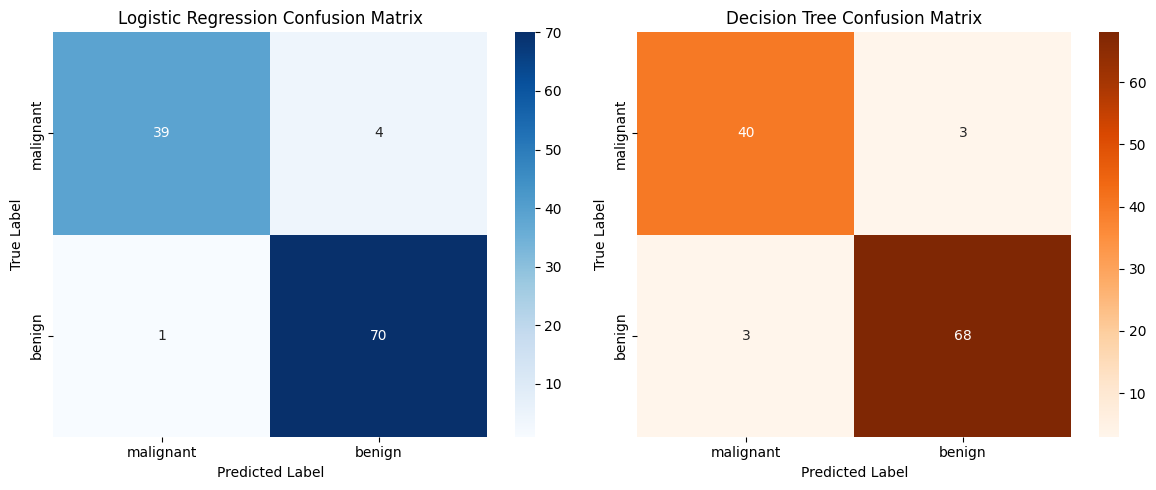

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Matrix
cm_log = confusion_matrix(y_test, pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
axes[0].set_title('Logistic Regression Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Decision Tree Matrix
cm_dt = confusion_matrix(y_test, pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=breast_cancer.target_names, yticklabels=breast_cancer.target_names)
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()